<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week04%EC%B6%94%EC%B2%9C%EC%8B%9C%EC%8A%A4%ED%85%9C2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 콘텐츠 기반 필터링 실습 - TMDB 5000 영화 데이터 세트

## 장르 속성을 이용한 영화 콘텐츠 기반 필터링

콘텐츠 기반 필터링은 사용자가 특정 영화를 감상하고 그 영화를 좋아했다면 그 영화와 비슷한 특성/속
성, 구성 요소 등을 가진 다른 영화를 추천하는 것

콘텐츠 기반 필터링 추천 시스템을 영화를 선택하는 데 중요한 요소인 영화 장르 속성을 기반으로 만들
어 보겠습니다. 장르 칼럼 값의 유사도를 비교한 뒤 그중 높은 평점을 가지는 영화를 추천하는 방식입
니다

In [ ]:
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')

movies=pd.read_csv('tmdb_5000_movies.csv')
print(movies.shape)
movies.head(1)

(4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""sp...",en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, ...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name"": ""Twentieth Century Fox Film Corporatio...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}, {""iso_3166_1"": ""GB"", ""name"": ""United ...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,Enter the World of Pandora.,Avatar,7.2,11800


 이 중 콘텐츠
기반 필터링 추천 분석에 사용할 주요 칼럼만 추출해 새롭게 DataFrame으로 만들겠습니다. 추출할 주
요 칼럼은 id, 영화제목 title, 영화가 속한 여러 가지 장르인 genres, 평균 평점인 vote_average, 평
점 투표수인 vote_count, 영화의 인기를 나타내는 popularity, 영화를 설명하는 주요 키워드 문구인
keywords, 영화에 대한 개요 설명인 overview

In [ ]:
movies_df=movies[['id','title','genres','vote_average','vote_count','popularity',
                  'keywords','overview']]

tmdb_5000_movies.csv 파일을 DataFrame에서 처리할 때 주의해야 할 칼럼이 있습니다.
‘genres’, ‘keywords’ 등과 같은 칼럼을 보면 [{"id"： 28, "name"： "Action"}, {"id"： 12, "name"：
"Adventure"}]와 같이 파이썬 리스트(list) 내부에 여러 개의 딕셔너리(diet)가 있는 형태의 문자열로
표기돼 있습니다. 이는 한꺼번에 여러 개의 값을 표현하기 위한 표기 방식입니다. 예를들어 영화‘아바
타’의 genres는 ‘Action’과 ‘Adventure’ 등의 여러 가지 장르로 구성될 수 있기 때문

In [ ]:
pd.set_option('max_colwidth',100)
movies_df[['genres','keywords']][:1]

,genres,keywords
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""sp..."


genres 칼럼의 문자열을 분해해서 개별 장르를 파이썬 리스트 객체로 추출

파이썬 ast 모듈의 literal_eval() 함수를 이용하면 이 문자열을 문자열이 의미하는 list [ dictl, dict2 ] 객체로 만들
수 있습니다

In [ ]:
from ast import literal_eval
movies_df['genres']=movies_df['genres'].apply(literal_eval)
movies_df['keywords']=movies_df['keywords'].apply(literal_eval)

이제 genres 칼럼은 문자열이 아니라 실제 리스트 내부에 여러 장르 딕셔너리로 구성된 객체를 가집
니다. [{"id"： 28, "name"： "Action"}, {"id"： 12, "name"： "Adventure"}]와 같은 genres 칼럼에서
['Action', 'Adventure1]와 같은 장르명만 리스트 객체로 추출

In [ ]:
movies_df['genres']=movies_df['genres'].apply(lambda x: [y['name'] for y in x])
movies_df['keywords']=movies_df['keywords'].apply(lambda x : [y['name'] for y in x])
movies_df[['genres','keywords']][:1]

,genres,keywords
0,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colony, society, space travel, futuristic, romance, spa..."


##장르 콘텐츠 유사도 측정

- 문자열로 변환된 genres 칼럼을 Count 기반으로 피처 벡터화 변환합니다.
- genres 문자열을 피처 벡터화 행렬로 변환한 데이터 세트를 코사인 유사도를 통해 비교합니다. 이를 위해 데이터 세트의
레코드별로 타 레코드와 장르에서 코사인 유사도 값을 가지는 객체를 생성합니다.
- 쟝르 유사도가 높은 영화 중에 평점이 높은 순으로 영화를 추천합니다.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

movies_df['genres_literal']=movies_df['genres'].apply(lambda x : (' ').join(x))
count_vect=CountVectorizer(min_df=0.0,ngram_range=(1,2))
genre_mat=count_vect.fit_transform(movies_df['genres_literal'])
print(genre_mat.shape)

(4803, 276)


In [ ]:
#cosine유사도
from sklearn.metrics.pairwise import cosine_similarity

genre_sim=cosine_similarity(genre_mat,genre_mat)
print(genre_sim.shape)
print(genre_sim[:2])

(4803, 4803)
[[1.         0.59628479 0.4472136  ... 0.         0.         0.        ]
 [0.59628479 1.         0.4        ... 0.         0.         0.        ]]


[영화0 기준 순위 리스트]  
[영화1 기준 순위 리스트]  
[영화2 기준 순위 리스트]  
이런 형태에서 0번째행 뽑은것

In [ ]:
# 비교 대상이 되는 행의 유사도 값이 높은 순으로 정렬된 행렬의 위치 인덱스 값을 추출
genre_sim_soreted_ind=genre_sim.argsort()[:,::-1]
print(genre_sim_soreted_ind[:1])

[[   0 3494  813 ... 3038 3037 2401]]


## 장르 콘텐츠 필터링을 이용한 영화 추천

이제 장르 유사도에 따라 영화를 추천하는 함수를 생성

In [ ]:
def find_sim_movies(df,sorted_ind,title_name,top_n=10):
    title_movie=df[df['title']==title_name]
    title_index=title_movie.index.values
    similar_indexes=sorted_ind[title_index,:(top_n)]
    print(similar_indexes)
    similar_indexes=similar_indexes.reshape(-1)
    return df.iloc[similar_indexes]

In [ ]:
similar_movies=find_sim_movies(movies_df,genre_sim_soreted_ind,'The Godfather',10)
similar_movies[['title','vote_average']]

[[2731 1243 3636 1946 2640 4065 1847 4217  883 3866]]


,title,vote_average
2731,The Godfather: Part II,8.3
1243,Mean Streets,7.2
3636,Light Sleeper,5.7
1946,The Bad Lieutenant: Port of Call - New Orleans,6.0
2640,Things to Do in Denver When You're Dead,6.7
4065,Mi America,0.0
1847,GoodFellas,8.2
4217,Kids,6.8
883,Catch Me If You Can,7.7
3866,City of God,8.1


이번에는 일단 좀 더 많은 후보군을 선정한 뒤에 영화의 평점에 따라 필터링해서 최종 추천하는 방식으
로 변경하겠습니다. 영화의 평점 정보인 ‘vote_average’ 값을 이용하겠습니다. vote_average를 적용
할 때 주의해야 할 점이 있습니다. vote_average는 0부터 10점 만점까지의 점수로 돼 있는데, 여러 관
객이 평가한 평점을 평균한 것입니다. 그런데 1명, 2명의 소수의 관객이 특정 영화에 만점이나 매우 높
은 평점을 부여해 왜곡된 데이터를 가지고 있습니다.

In [ ]:
movies_df[['title','vote_average','vote_count']].sort_values('vote_average',ascending=False)[:10]

,title,vote_average,vote_count
3519,Stiff Upper Lips,10.0,1
4247,Me You and Five Bucks,10.0,2
4045,"Dancer, Texas Pop. 81",10.0,1
4662,Little Big Top,10.0,1
3992,Sardaarji,9.5,2
2386,One Man's Hero,9.3,2
2970,There Goes My Baby,8.5,2
1881,The Shawshank Redemption,8.5,8205
2796,The Prisoner of Zenda,8.4,11
3337,The Godfather,8.4,5893


유명한 영화 평점 사이트인 IMDB에서는 평가 횟수에 대한 가중치가 부여된 평점(Weighted Rating)
방식을 사용

가중 평점(Weighted Rating) = (v/(v+m)) * R + (m/(v+m)) * C

- V：개별 영화에평점을 투표한 횟수
- m： 평점을 부여하기위한 최소 투표횟수
- R： 개별 영화에 대한 평균 평점.
- C： 전체 영화에 대한 평균 평점.

 m 값은 전체 투표 횟수에서 상위 60%에 해당하는 횟수를 기준으로 정
하겠습니다

In [ ]:
C=movies_df['vote_average'].mean()
m=movies_df['vote_count'].quantile(0.6)
print('C: ',round(C,3),'m: ',round(m,3))

C:  6.092 m:  370.2


In [ ]:
percentile=0.6
m=movies_df['vote_count'].quantile(percentile)
C=movies_df['vote_average'].mean()

def weighted_vote_average(record):
    v=record['vote_count']
    R=record['vote_average']
    return ((v/(v+m))*R+((m/(m+v))*C))
movies_df['weighted_vote']=movies.apply(weighted_vote_average,axis=1)

In [ ]:
movies_df[['title','vote_average','weighted_vote','vote_count']].sort_values('weighted_vote',ascending=False)[:10]

,title,vote_average,weighted_vote,vote_count
1881,The Shawshank Redemption,8.5,8.396052,8205
3337,The Godfather,8.4,8.263591,5893
662,Fight Club,8.3,8.216455,9413
3232,Pulp Fiction,8.3,8.207102,8428
65,The Dark Knight,8.2,8.136930,12002
1818,Schindler's List,8.3,8.126069,4329
3865,Whiplash,8.3,8.123248,4254
809,Forrest Gump,8.2,8.105954,7927
2294,Spirited Away,8.3,8.105867,3840
2731,The Godfather: Part II,8.3,8.079586,3338


이제 새롭게 정의된 평점 기준에 따라서 영화를 추천해 보겠습니다. 장르 유사성이 높은 영화를 top_n
의 2배수만큼 후보군으로 선정한 뒤에 weighted_vote 칼럼 값이 높은 순으로 top_n만큼 추출하는 방 식으로 find_sim_movie () 함수를 변경

In [ ]:
def find_sim_movies(df,sorted_ind,title_name,top_n=10):
    title_movie=df[df['title']==title_name]
    title_index=title_movie.index.values

    similar_indexes=sorted_ind[title_index,:(top_n*2)]
    similar_indexes=similar_indexes.reshape(-1)

    similar_indexes=similar_indexes[similar_indexes !=title_index]

    return df.iloc[similar_indexes].sort_values('weighted_vote',ascending=False)[:top_n]
similar_movies=find_sim_movies(movies_df,genre_sim_soreted_ind,'The Godfather',10)
similar_movies[['title','vote_average','weighted_vote']]

,title,vote_average,weighted_vote
2731,The Godfather: Part II,8.3,8.079586
1847,GoodFellas,8.2,7.976937
3866,City of God,8.1,7.759693
1663,Once Upon a Time in America,8.2,7.657811
883,Catch Me If You Can,7.7,7.557097
281,American Gangster,7.4,7.141396
4041,This Is England,7.4,6.739664
1149,American Hustle,6.8,6.717525
1243,Mean Streets,7.2,6.626569
2839,Rounders,6.9,6.530427


# 06 아이템 기반 최근접 이웃 협업 필터링 실습

In [ ]:
import pandas as pd
import numpy as np

movies=pd.read_csv('./ml-latest-small/movies.csv')
ratings=pd.read_csv('./ml-latest-small/ratings.csv')
print(movies.shape)
print(ratings.shape)

(9742, 3)
(100836, 4)


협업 필터링은 이 ratings.csv 데이터 세트와 같이 사용자와 아이템 간의 평점（또는 다른 유형의 액션）
에 기반해 추천하는 시스템입니다. ratings.csv의 DataFrame인 ratings를 이용해 아이템 기반의 최근
접 이웃 협업 필터링을 구현해 보겠습니다. 먼저 로우（행） 레벨 형태의 원본 데이터 세트를 다음 그림
과 같이 모든 사용자를 로우로, 모든 영화를 칼럼으로 구성한 데이터 세트로 변경해야 합니다

이 같은 변환은 DataFrame 의 pivot_table() 함수를 이
용하면 쉽게 할 수 있습니다.

In [ ]:
ratings=ratings[['userId','movieId','rating']]
ratings_matrix=ratings.pivot_table('rating',index='userId',columns='movieId')
ratings_matrix.head(3)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 가독성을 높이기 위해 칼럼명을 movield가 아닌 영
화명 title로 변경하겠습니다. 영화명은 ratings에 존재하지 않고 movies 데이터 세트에 존재합니다.
ratings와 movies를 조인해 title 칼럼을 가져온 뒤에 pivot_table()의 인자로 columns에 ‘movield’
가 아닌 ‘title’을 입력해 title로 피벗(pivot)하겠습니다. 이후에 NaN은 0으로 변환합니다

In [ ]:
rating_movies=pd.merge(ratings,movies,on='movieId')
ratings_matrix=rating_movies.pivot_table('rating',index='userId',columns='title')

ratings_matrix=ratings_matrix.fillna(0)
ratings_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 영화 간 유사도 산출

다음 그림에서도 볼 수 있듯이 cosine_similaritiy() 함수는 행을 기준으로 서로 다른 행을
비교해 유사도를 산출합니다. 그런데 ratings_matrix는 userid가 기준인 행 레벨 데이터이므로 여기
에 cosine_similarity()를 적용하면 영화 간의 유사도가 아닌 사용자 간의 유사도가 만들어집니다  
 cosine_similarity() 함수는 기준행과 타 행을 비교하여 유사도 산출   
 행 기준이 영화가 되고
열 기준이 사용자가 돼야 합니다.

In [ ]:
ratings_matrix_T=ratings_matrix.transpose()
ratings_matrix_T.head(3)

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Round Midnight (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

item_sim=cosine_similarity(ratings_matrix_T,ratings_matrix_T)
item_sim_df=pd.DataFrame(data=item_sim,index=ratings_matrix.columns,
                         columns=ratings_matrix.columns)
print(item_sim_df.shape)
item_sim_df.head(3)

(9719, 9719)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),1.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.141653,0.0,...,0.0,0.342055,0.543305,0.707107,0.0,0.0,0.139431,0.327327,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Round Midnight (1986),0.0,0.707107,1.000000,0.0,0.0,0.0,0.176777,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0


In [ ]:
item_sim_df['Godfather, The (1972)'].sort_values(ascending=False)[:6]

title
Godfather, The (1972)                        1.000000
Godfather: Part II, The (1974)               0.821773
Goodfellas (1990)                            0.664841
One Flew Over the Cuckoo's Nest (1975)       0.620536
Star Wars: Episode IV - A New Hope (1977)    0.595317
Fargo (1996)                                 0.588614
Name: Godfather, The (1972), dtype: float64

In [ ]:
item_sim_df['Inception (2010)'].sort_values(ascending=False)[1:6]

title
Dark Knight, The (2008)          0.727263
Inglourious Basterds (2009)      0.646103
Shutter Island (2010)            0.617736
Dark Knight Rises, The (2012)    0.617504
Fight Club (1999)                0.615417
Name: Inception (2010), dtype: float64

## 아이템 기반 최근접 이웃 협업 필터링으로 개인화된 영화 추천

이번 절에서는 영화 유사도 데이터를 이용해
최근접 이웃 협업 필터링으로 개인에게 최적화된 영화추천을 구현해 보겠습니다. 개인화된 영화추천
의 가장 큰 특징은 개인이 아직 관람하지 않은 영화를 추천한다는 것입니다. 아직 관람하지 않은 영화
에 대해서 아이템 유사도와 기존에 관람한 영화의 평점 데이터를 기반으로 해 새롭게 모든 영화의 예측
평점을 계산한 후 높은 예측 평점을 가진 영화를 추천하는 방식입니다.

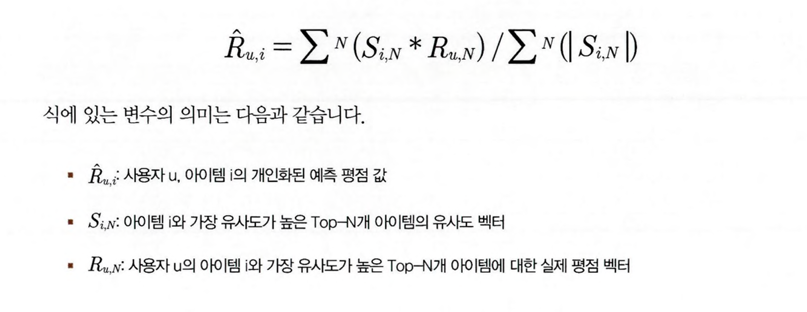

In [ ]:
def predict_rating(ratings_arr,item_sim_arr):
    rating_pred=ratings_arr.dot(item_sim_arr)/np.array([np.abs(item_sim_arr).sum(axis=1)])
    return rating_pred

In [ ]:
ratings_pred=predict_rating(ratings_matrix.values,item_sim_df.values)
ratings_pred_matrix=pd.DataFrame(data=ratings_pred,index=ratings_matrix.index,
                                 columns=ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.070345,0.577855,0.321696,0.227055,0.206958,0.194615,0.249883,0.102542,0.157084,0.178197,...,0.113608,0.181738,0.133962,0.128574,0.006179,0.212070,0.192921,0.136024,0.292955,0.720347
2,0.018260,0.042744,0.018861,0.000000,0.000000,0.035995,0.013413,0.002314,0.032213,0.014863,...,0.015640,0.020855,0.020119,0.015745,0.049983,0.014876,0.021616,0.024528,0.017563,0.000000
3,0.011884,0.030279,0.064437,0.003762,0.003749,0.002722,0.014625,0.002085,0.005666,0.006272,...,0.006923,0.011665,0.011800,0.012225,0.000000,0.008194,0.007017,0.009229,0.010420,0.084501


In [ ]:
from sklearn.metrics import mean_squared_error

def get_mse(pred,actual):
    pred=pred[actual.nonzero()].flatten()
    actual=actual[actual.nonzero()].flatten()
    return mean_squared_error(pred,actual)
print('아이템 기반 모든 최근접 이웃 MSE:',get_mse(ratings_pred,ratings_matrix.values))

아이템 기반 모든 최근접 이웃 MSE: 9.895354759094706


특정 영화와 가장 비슷한 유사도를 가지는 영화에 대해서만 유사도 벡터를 적
용하는 함수로 변경하겠습니다. predict_rating_topsim(ratings_arr, item_sim_arr, n=20)함수는
predict_rating() 함수와 유사하지만 n 인자를 가지고 있어서 Top-N 유사도를 가지는 영화 유사도
벡터만 예측값을 계산하는 데 적용합니다. 아쉬운 점은 이러한 계산을 위해서는 개별 예측값을 구하기
위해서 행, 열 별로 for 루프를 반복 수행하면서 Top-N 유사도 벡터를 계산해야 하기 때문에 수행시
간이 오래 걸린다는 점입니다.

In [ ]:
def predict_rating_topsim(ratings_arr,item_sim_arr,n=20):
    pred=np.zeros(ratings_arr.shape)
    for col in range(ratings_arr.shape[1]):
        top_n_items=[np.argsort(item_sim_arr[:,col])[:-n-1:-1]]
        for row in range(ratings_arr.shape[0]):
            pred[row,col]=item_sim_arr[col,:][top_n_items].dot(ratings_arr[row,:][top_n_items].T)
            pred[row,col]/=np.sum(np.abs(item_sim_arr[col,:][top_n_items]))
    return pred


In [ ]:
ratings_pred=predict_rating_topsim(ratings_matrix.values,
                                   item_sim_df.values,n=20)
print('아이템 기반 최근접 Top-20 이웃 MSE',get_mse(ratings_pred,ratings_matrix.values))
ratings_pred_matrix=pd.DataFrame(data=ratings_pred,index=ratings_matrix.index,
                                 columns=ratings_matrix.columns)

아이템 기반 최근접 Top-20 이웃 MSE 3.694999233129397


In [ ]:
user_rating_id=ratings_matrix.loc[9,:]
user_rating_id[user_rating_id>0].sort_values(ascending=False)[:10]


title
Adaptation (2002)                                                                 5.0
Citizen Kane (1941)                                                               5.0
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)    5.0
Producers, The (1968)                                                             5.0
Lord of the Rings: The Two Towers, The (2002)                                     5.0
Lord of the Rings: The Fellowship of the Ring, The (2001)                         5.0
Back to the Future (1985)                                                         5.0
Austin Powers in Goldmember (2002)                                                5.0
Minority Report (2002)                                                            4.0
Witness (1985)                                                                    4.0
Name: 9, dtype: float64

In [ ]:
def get_unseen_movies(ratings_matrix,userId):
    user_rating=ratings_matrix.loc[userId,:]
    already_seen=user_rating[user_rating>0].index.tolist()
    movies_list=ratings_matrix.columns.tolist()
    unseen_list=[movie for movie in movies_list if movie not in already_seen]
    return unseen_list

In [ ]:
def recomm_movie_by_userid(pred_df,userId,unseen_list,top_n=10):
    recomm_movies=pred_df.loc[userId,unseen_list].sort_values(ascending=False)[:top_n]
    return recomm_movies
unseen_list=get_unseen_movies(ratings_matrix,9)
recomm_movies=recomm_movie_by_userid(ratings_pred_matrix,9,unseen_list,top_n=10)
recomm_movies=pd.DataFrame(data=recomm_movies.values,index=recomm_movies.index,columns=['pred_score'])
recomm_movies

,pred_score
title,
Shrek (2001),0.866202
Spider-Man (2002),0.857854
"Last Samurai, The (2003)",0.817473
Indiana Jones and the Temple of Doom (1984),0.816626
"Matrix Reloaded, The (2003)",0.800990
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001),0.765159
Gladiator (2000),0.740956
"Matrix, The (1999)",0.732693
Pirates of the Caribbean: The Curse of the Black Pearl (2003),0.689591
